In [1]:
# The exclamation mark tells Colab to run this as a terminal command
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00


In [2]:

import torch
from google.colab import drive
from ultralytics import YOLO
import os
import shutil


# ---------------------------------------------------------
# Step 1: Kết nối kho lưu trữ Google Drive
# ---------------------------------------------------------
drive.mount('/content/drive')

# Khai báo đường dẫn cố định trên Google Drive
project_path = "/content/drive/MyDrive/YOLO_Container_Project_TransferLearning"
run_name = "Training_Run_Pro_TransferLearning"


last_weights_path = f"{project_path}/{run_name}/weights/last.pt"
best_weights_path = f"{project_path}/{run_name}/weights/best.pt"
csv_path = f"{project_path}/{run_name}/results.csv"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
# ---------------------------------------------------------
# Step 2: Huấn luyện Mô hình
# ---------------------------------------------------------
if os.path.exists(last_weights_path):                         # Kiểm tra nếu có model cũ, thì sử dụng để training tiếp bằng resume=True
    print(f"Phát hiện tiến độ cũ tại: {last_weights_path}")
    print("Đang khôi phục hệ thống...")
    my_model = YOLO(last_weights_path)                        # Load lại Model cũ
    my_model.train(resume=True)                               # Resume training với Model cũ
else:
    # --------------------------------------------------------- Kiến thức buổi 36 (Huấn luyện mô hình Theo hướng Transfer Learning từ yolov8n)---------------------------------------------------------
    print("Khởi tạo huấn luyện Transfer Learning với các Best Practices...")
    my_model = YOLO("yolov8n.pt")


    my_model.train(
        # --------------------------------------------------------- Kiến thức buổi 39 (Phân loại hình ảnh để chuẩn bị dữ liệu)---------------------------------------------------------
        data="/content/drive/MyDrive/Colab Notebooks/Data/Dataset/data.yaml",
        epochs=100,             # Có thể Tăng lên 100 epochs vì chúng ta đã có Early Stopping bảo vệ
        imgsz=640,              # Resize hình về cùng kích thước
        project=project_path,
        name=run_name,

        # --------------------------------------------------------- Kiến thức buổi 37 (Tăng cường dữ liệu, Tối ưu mô hình)---------------------------------------------------------
        seed=42,                # Đảm bảo tính lặp lại (Reproducibility).
        optimizer='AdamW',      # Thuật toán tối ưu hiện đại nhất, vượt trội hơn SGD.
        cache=True,             # Đẩy toàn bộ ảnh lên RAM để đọc siêu tốc.
        patience=15,            # Early Stopping: Tự động dừng nếu mAP không tăng sau 15 epochs liên tiếp.

        # Tối ưu tốc độ
        amp=True,               # Automatic Mixed Precision
        workers=8,              # Số luồng CPU
        batch=16,               # Kích thước batch

        # Tối ưu Learning Rate & tránh Overfitting
        cos_lr=True,            # Learning Rate dạng hình Sin/ Cosine
        lr0=0.001,              # AdamW thường bắt đầu với learning rate nhỏ hơn SGD.
        weight_decay=0.0005,    # Tránh học vẹt

        # Data Augmentation (Tăng cường dữ liệu)
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,    # Biến đổi màu sắc, độ sáng
        degrees=10.0,           # Xoay ảnh tối đa 10 độ
        fliplr=0.5,             # Lật ngang 50%
        mosaic=1.0              # Ghép ngẫu nhiên 4 ảnh thành 1
    )

Phát hiện tiến độ cũ tại: /content/drive/MyDrive/YOLO_Container_Project_TransferLearning/Training_Run_Pro_TransferLearning/weights/last.pt
Đang khôi phục hệ thống...
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Data/Dataset/data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lr

In [ ]:
# ---------------------------------------------------------
# Step 3: Tính toán Metrics trên Valid Set
# ---------------------------------------------------------
print("\n--- ĐANG ĐÁNH GIÁ TRÊN VALID SET ---")
# Lưu ý quan trọng: Phải nạp lại 'best.pt' vì Early Stopping có thể làm
# mô hình hiện tại dừng ở một epoch có kết quả thấp hơn đỉnh cao.
final_model = YOLO(best_weights_path)
metrics = final_model.val()

mean_precision = metrics.results_dict['metrics/precision(B)']
mean_recall = metrics.results_dict['metrics/recall(B)']
mean_map50 = metrics.results_dict['metrics/mAP50(B)']
mean_map50_95 = metrics.results_dict['metrics/mAP50-95(B)']

if (mean_precision + mean_recall) == 0:
    mean_f1 = 0.0
else:
    mean_f1 = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall)

print("\nTổng quan (All Classes):")
print(f"- Precision: {mean_precision:.4f}")
print(f"- Recall:    {mean_recall:.4f}")
print(f"- F1-Score:  {mean_f1:.4f}")
print(f"- mAP@50:    {mean_map50:.4f}")
print(f"- mAP@50:95: {mean_map50_95:.4f}\n")

print("Chi tiết mAP@50 theo từng Class:")
class_names = final_model.names
for i, class_id in enumerate(metrics.ap_class_index):
    class_map50 = metrics.class_result(i)[2]
    print(f"- {class_names[class_id]}: {class_map50:.4f}")


--- ĐANG ĐÁNH GIÁ TRÊN VALID SET ---
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.5 ms, read: 0.2±0.1 MB/s, size: 76.1 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Data/Dataset/valid/labels.cache... 1157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1157/1157 134.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 136, len(boxes) = 3060. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 73/73 5.3s/it 6:24
                   all       1157       3060      0.294      0.252      0.197     0.0757
                  dent        564        959      0.315    


Đang tiến hành vẽ biểu đồ Loss và mAP...


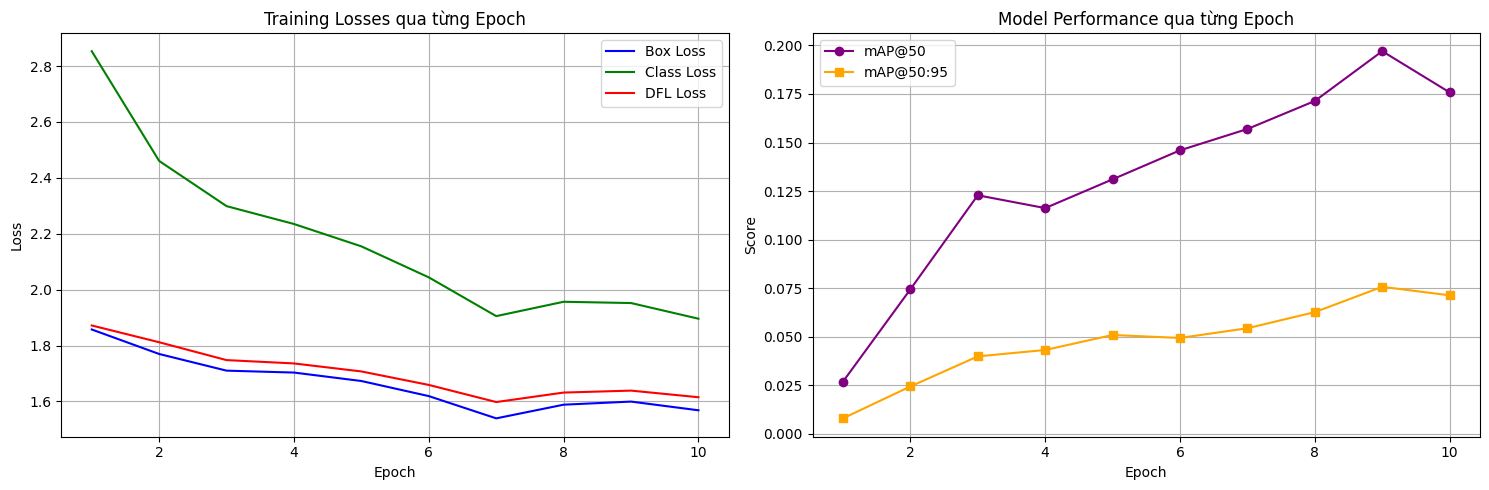

Đã lưu biểu đồ thành công tại: '/content/drive/MyDrive/YOLO_Container_Project_TransferLearning/Training_Run_Pro_TransferLearning/Custom_Training_Charts.png'!


In [ ]:
# ---------------------------------------------------------
# Step 4: Tự vẽ biểu đồ từ File Nhật ký (results.csv)
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

print("\nĐang tiến hành vẽ biểu đồ Loss và mAP...")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='blue')
    axes[0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', color='green')
    axes[0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', color='red')
    axes[0].set_title('Training Losses qua từng Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='purple', marker='o')
    axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50:95', color='orange', marker='s')
    axes[1].set_title('Model Performance qua từng Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    # Lưu file ảnh trực tiếp lên Google Drive
    chart_path = f"{project_path}/{run_name}/Custom_Training_Charts.png"
    plt.savefig(chart_path)
    plt.show()
    print(f"Đã lưu biểu đồ thành công tại: '{chart_path}'!")
else:
    print(f"Lỗi: Không tìm thấy file {csv_path} trên Drive.")

In [ ]:
# ---------------------------------------------------------
# Step 5: Đánh giá và Xuất mô hình sang chuẩn ONNX
# ---------------------------------------------------------
print("\nĐang xuất mô hình sang định dạng ONNX để triển khai lên Streamlit...")
# final_model đã nạp sẵn best.pt ở Step 3, ta chỉ việc xuất ra
exported_paths = final_model.export(format="onnx", half=True)

print(f"\nTuyệt vời! Mô hình triển khai siêu nhẹ đã sẵn sàng tại: {exported_paths}")


Đang xuất mô hình sang định dạng ONNX để triển khai lên Streamlit...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/YOLO_Container_Project_TransferLearning/Training_Run_Pro_TransferLearning/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (23.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 356ms
Prepared 4 packages in 2.56s
Installed 4 packages in 352ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.9s
WARNING 